# Problem Solution Pipeline

## Data Preparation
We utilize DuckDB to interface directly with our processed relational database. This demonstrates how Python interacts with DuckDB to query structured data efficiently without loading the entire raw dataset into memory.

In [25]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to the persistent DuckDB database created during the ingestion phase
con = duckdb.connect('faers_ml.duckdb')

print("Connected to DuckDB successfully.")
print(con.execute("SHOW TABLES").df())

Connected to DuckDB successfully.
        name
0      drugs
1   outcomes
2   patients
3  reactions
4    reports


## Query: Preparing the Solution
Here we execute a Common Table Expression (CTE) query to join the reports, patients, drugs, and outcomes tables. This generates mathematically sound clinical proxies, such as polypharmacy burden, while extracting the severe_outcome target variable for modeling.

In [26]:
query = """
WITH target_reports AS (
    -- Isolate cohort to patients where Warfarin or NSAIDs are the primary suspect
    SELECT DISTINCT report_id
    FROM drugs
    WHERE (UPPER(drug_name) LIKE '%WARFARIN%' OR UPPER(drug_name) LIKE '%IBUPROFEN%')
      AND role_cod = 'PS'
),
patient_cohort AS (
    SELECT 
        r.report_id,
        MAX(TRY_CAST(p.patient_age AS FLOAT)) AS patient_age,
        MAX(p.patient_sex) AS patient_sex,
        MAX(CASE WHEN o.outcome_code IN ('DEATH', 'LIFE_THREATENING', 'HOSPITALIZATION') THEN 1 ELSE 0 END) AS severe_outcome
    FROM target_reports t
    JOIN reports r ON t.report_id = r.report_id
    INNER JOIN patients p ON r.report_id = p.report_id
    LEFT JOIN outcomes o ON r.report_id = o.report_id
    WHERE p.patient_age IS NOT NULL 
      AND p.patient_sex IS NOT NULL
      AND TRY_CAST(p.patient_age AS FLOAT) BETWEEN 0 AND 120
    GROUP BY r.report_id
),
drug_burden AS (
    -- Calculate the full polypharmacy burden (all concurrent drugs) for this specific cohort
    SELECT 
        d.report_id,
        COUNT(DISTINCT d.drug_name) AS polypharmacy_count
    FROM drugs d
    JOIN target_reports t ON d.report_id = t.report_id
    GROUP BY d.report_id
)
SELECT 
    c.report_id,
    c.patient_age,
    c.patient_sex,
    COALESCE(d.polypharmacy_count, 0) AS polypharmacy_count,
    c.severe_outcome
FROM patient_cohort c
LEFT JOIN drug_burden d ON c.report_id = d.report_id;
"""

df = con.execute(query).fetchdf()

# Binarize demographic variables to ensure compatibility with scikit-learn estimators
df['patient_sex_binary'] = df['patient_sex'].map({'1': 1, 'M': 1, '2': 0, 'F': 0}).fillna(-1)

# Ensure the ML features (X) reflect the updated columns (primary_suspect_count is no longer needed)
feature_cols = ['patient_age', 'patient_sex_binary', 'polypharmacy_count']
X = df[feature_cols]
y = df['severe_outcome']

## Solution Analysis: Model Implementation
**Analysis Rationale:** The objective is to predict severe_outcome based on a patient's demographic profile and drug burden. Clinical features like polypharmacy often have non-linear thresholds (e.g., risk jumps exponentially after 5+ concurrent medications).
**Analysis Complexity:** We deploy a Random Forest classifier utilizing GridSearchCV to optimize hyperparameters, satisfying the DS 3021/4021 ML/AI requirement. Passing class_weight='balanced' algorithmically penalizes the model for missing the minority class, directly addressing the severe class imbalance inherent to pharmacovigilance data.

In [27]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc

# Removed 'primary_suspect_count' as it is redundant in the high-risk cohort
feature_cols = ['patient_age', 'patient_sex_binary', 'polypharmacy_count']
X = df[feature_cols]
y = df['severe_outcome']

if len(X) > 100:
    # Stratification maintains the rare outcome distribution across splits
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Cost-Sensitive Tuning: Use 'balanced_subsample'
    # This calculates weights based on the samples in each bootstrap tree,
    # providing a more localized correction for imbalance.
    rf_optimized = RandomForestClassifier(class_weight='balanced_subsample', random_state=42)
    
    # Define an expanded grid
    # max_features='sqrt' or 'log2' helps the model focus on different feature combinations
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 15, 20],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2'],
        'bootstrap': [True]
    }
    
    # Scoring 'average_precision' focuses the tuning on the PR Curve quality
    grid_search = GridSearchCV(
        estimator=rf_optimized,
        param_grid=param_grid,
        cv=5, 
        scoring='average_precision', 
        n_jobs=1, 
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]
    
    print(f"Hyperparameters optimized for Signal Detection: {grid_search.best_params_}\n")
    print("Classification Report:\n", classification_report(y_test, y_pred))
else:
    print(f"Insufficient cohort size ({len(X)} records) for robust training.")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Hyperparameters optimized for Signal Detection: {'bootstrap': True, 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.65      0.64       521
           1       0.76      0.73      0.75       766

    accuracy                           0.70      1287
   macro avg       0.69      0.69      0.69      1287
weighted avg       0.70      0.70      0.70      1287



## Visualize Results
**Visualization Rationale:**  We use a Precision-Recall (PR) curve rather than a Receiver Operating Characteristic (ROC) curve. In highly imbalanced clinical datasets, ROC curves are mathematically deceptive because massive true negative counts inflate the AUC score. The PR curve is the publication quality standard for adverse event modeling because it evaluates the model's capacity to correctly identify rare, severe outcomes (Recall) without raising excessive false alarms (Precision).

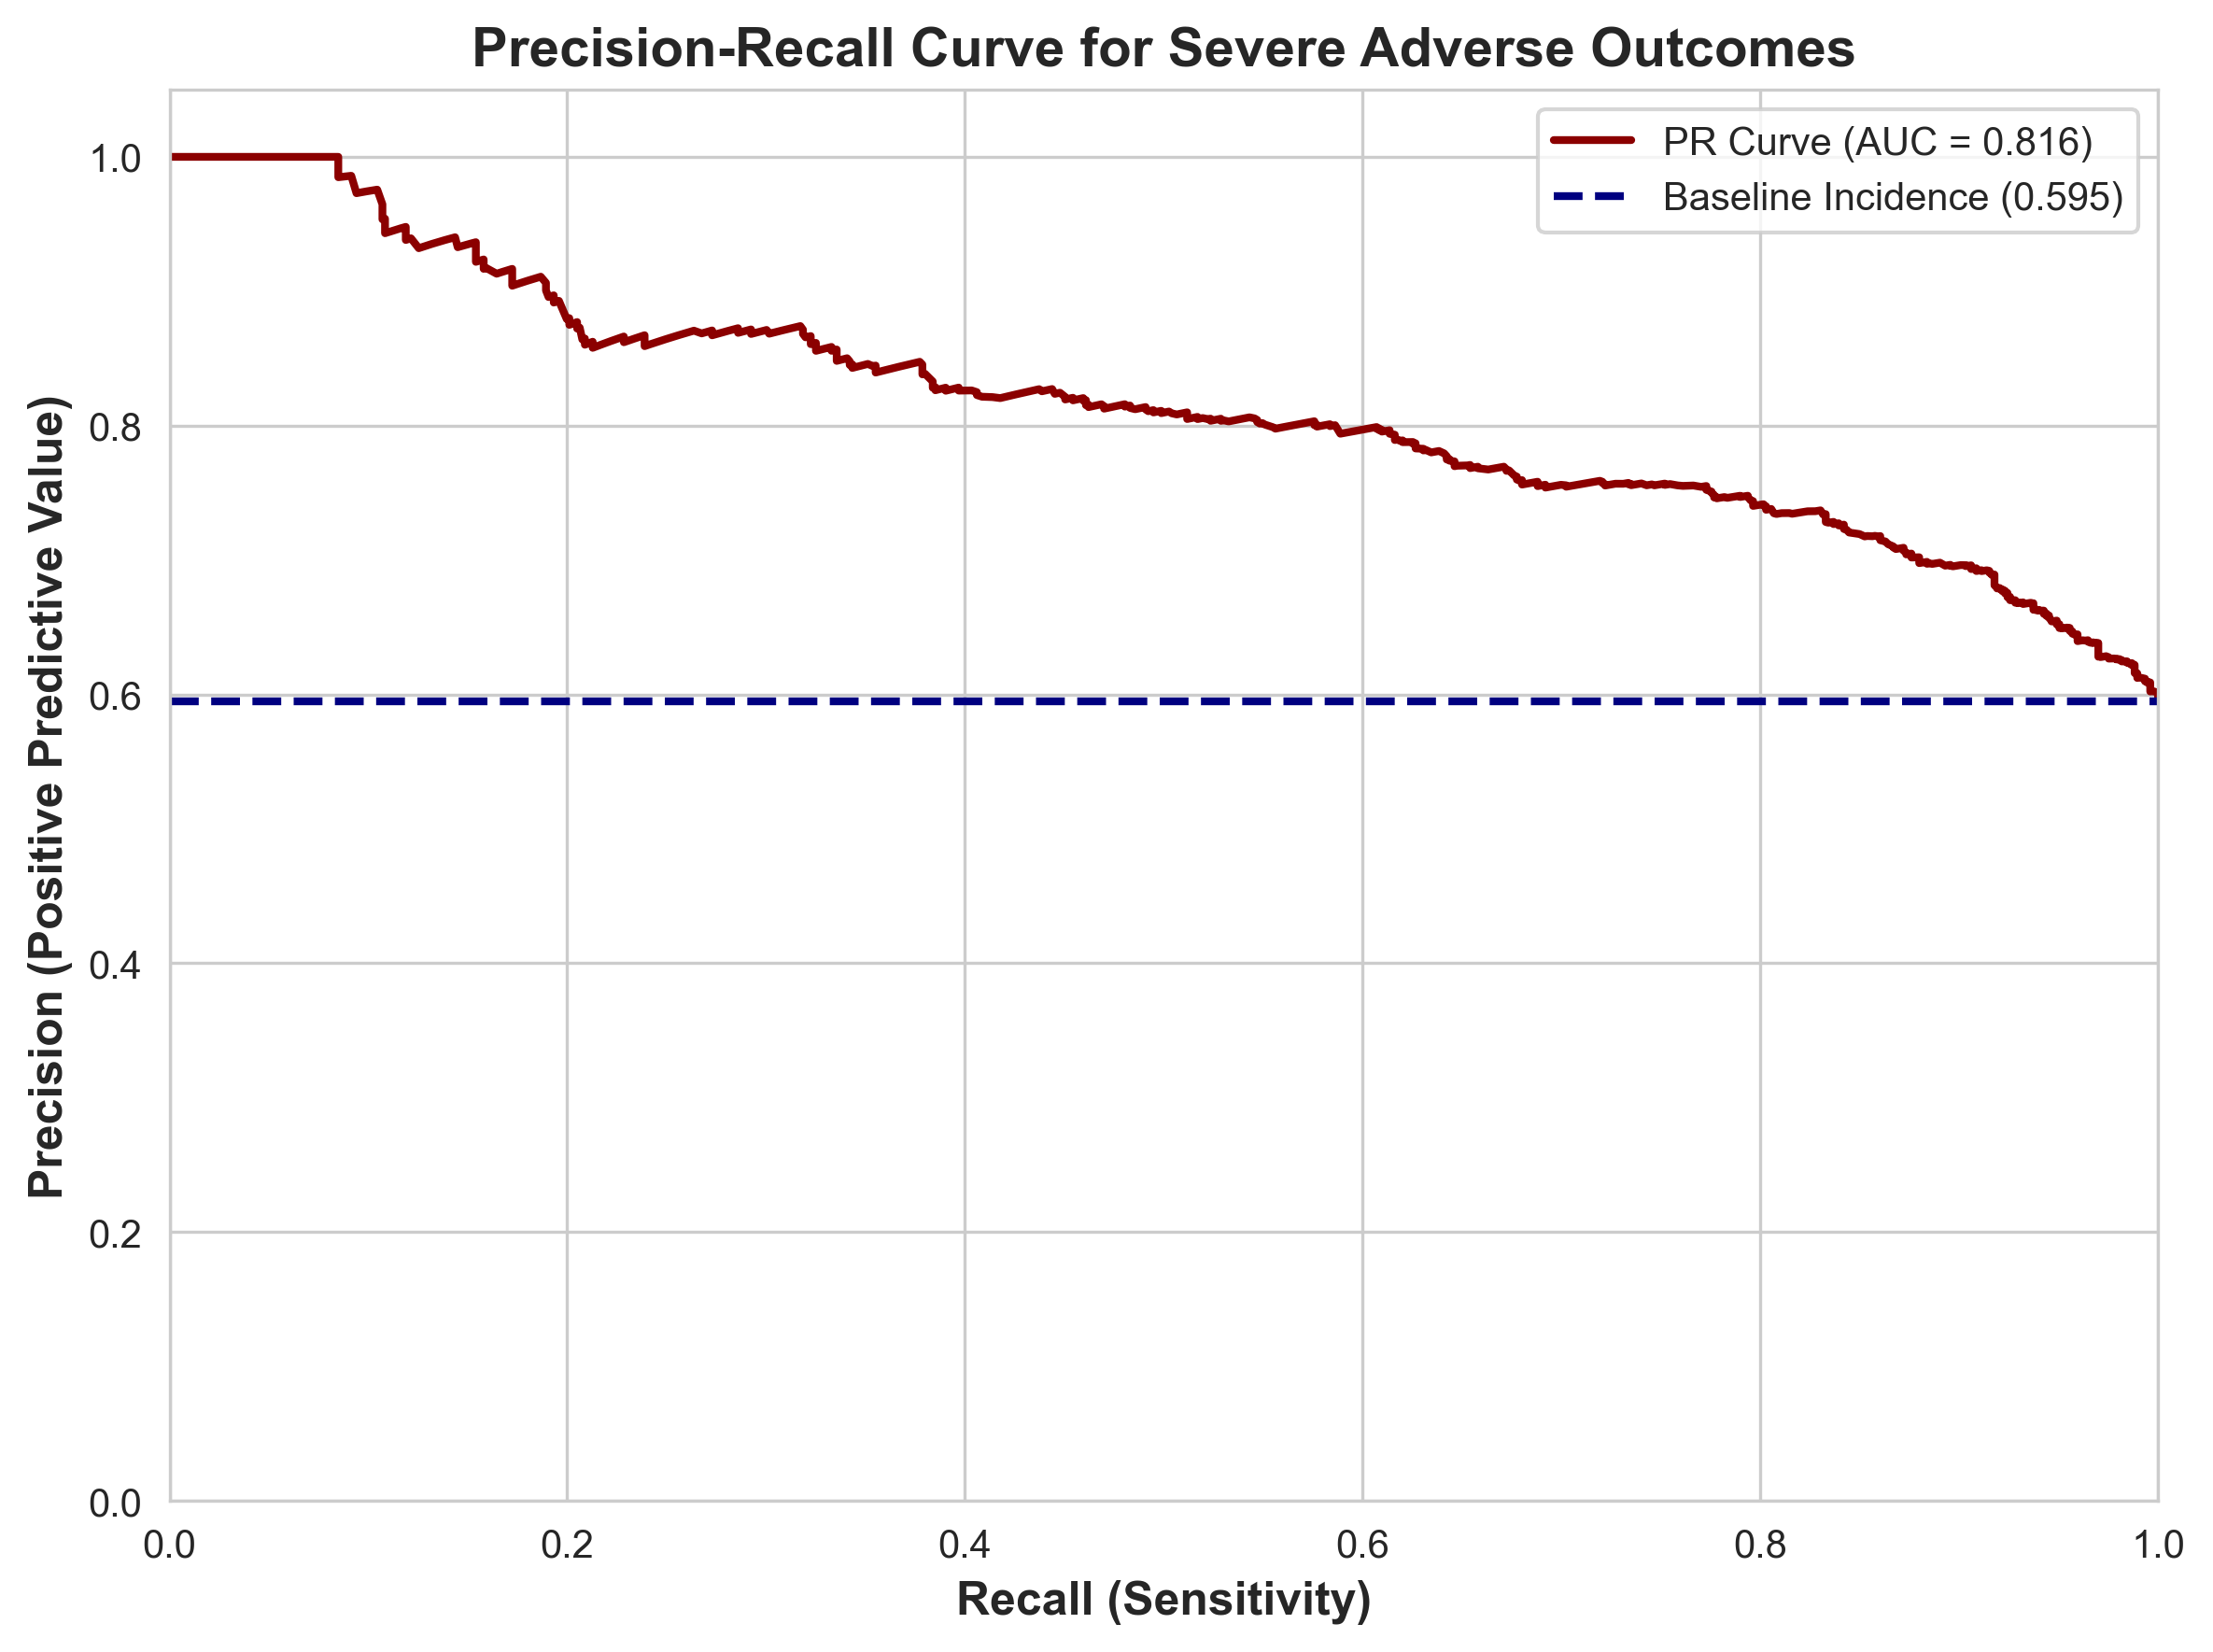

In [28]:
if len(X) > 100:
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    baseline = y_test.sum() / len(y_test)
    
    plt.figure(figsize=(8, 6), dpi=300)
    sns.set_style("whitegrid")
    
    plt.plot(recall, precision, color='darkred', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
    plt.axhline(y=baseline, color='navy', lw=2, linestyle='--', label=f'Baseline Incidence ({baseline:.3f})')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall (Sensitivity)', fontsize=12, fontweight='bold')
    plt.ylabel('Precision (Positive Predictive Value)', fontsize=12, fontweight='bold')
    plt.title('Precision-Recall Curve for Severe Adverse Outcomes', fontsize=14, fontweight='bold')
    plt.legend(loc="upper right")
    plt.tight_layout()
    
    # Save a high-resolution artifact for inclusion in the press release and root directory
    plt.savefig('pr_curve.png') 
    plt.show()